In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from library import *
from scipy.stats import norm
from math import *

# Barrier Option

## BS

In [2]:
def barrier_BS(r, q, T, J, So, k, sigma, rand, Bl, Bh, N): 

    '''
    Returns the prices of the down-and-out call, up-and-out put and
    double-barrier options for every trajectory generated with BS model

    @ r                    interest rate
    @ q                    dividend yield
    @ T                    maturity
    @ J                    number of simulations
    @ So                   initial underlying price
    @ k                    strike price
    @ sigma                asset volatility
    @ rand                 random object
    @ Bl                   lower barrier
    @ Bh                   higher barrier
    @ N                    number of time steps
    '''

    dt = T / N
    S = BS_trj(rand, N, So, T, J, sigma)

    # From martingale to S
    D_tT = exp((r-q)*dt)
    b = 1
    for n in range(N):
        b *= D_tT
        S[n] *= b

    min_S = np.min(S, axis = 0)
    max_S = np.max(S, axis = 0)

    ST = S[N]
    payoff = ST - k 

    # DOC
    mask_doc = np.logical_and(payoff > 0, min_S > Bl)
    doc = np.where(mask_doc, payoff, 0)
    doc *= np.exp((q-r) * T)

    # UOP
    mask_uop = np.logical_and(-payoff > 0, max_S < Bh)
    uop = np.where(mask_uop, -payoff, 0)
    uop *= np.exp((q-r) * T)

    # DB
    mask_db = np.logical_and(Bl < min_S, max_S < Bh)
    db = np.where(mask_db, ST, 0)
    db *= np.exp((q-r) * T)


    return doc, uop, db

In [7]:
def mc_barrier_BS(**kwargs ):

    So    = kwargs.get("So",1)               # initial value of the underlying
    T     = kwargs.get("T",1)                # maturity
    N     = kwargs.get("N",52)               # number of periods
    r     = kwargs.get("r",.015)             # interest rate
    q     = kwargs.get("q", 0.0)             # dividend yield
    k     = kwargs.get("strike",1.2)         # strike 
    Js    = kwargs.get("Js",(14,16,18,20))   # number of trajectories
    sigma = kwargs.get("sigma",.2)           # standard deviation       
    Bl    = kwargs.get("Bl", 0.4)            # low barrier
    Bh    = kwargs.get("Bh",1.6)             # high barrier
    Seed  = kwargs.get("Seed", 1907)
 
    print("@ %-16s %8.4f"  %("So", So))
    print("@ %-16s %8.4f"  %("Strike", k))
    print("@ %-16s %8.4f"  %("sigma", sigma))
    print("@ %-16s %8.4f"  %("T" , T))
    print("@ %-16s %8.4f"  %("r" , r))
    print("@ %-16s %8.4f"  %("q" , q))
    print("@ %-16s %8d"    %("Nt" , N))
    print("@ %-12s %8.2f"  %("Low barrier (Bl)" , Bl))
    print("@ %-12s %8.2f"  %("High barrier(Bh)" , Bh))
    print("\n");
    
    rand = np.random.RandomState()
    rand.seed(Seed)

    mcDOC = {}
    mcUOP = {}
    mcDB  = {}

    T0 = Timer()
    for j in Js:
        T0.start()
        J = ( 1 << j )
        DOC, UOP, DB = barrier_BS(r, q, T, J, So, k, sigma, rand, Bl, Bh, N)
        mcDOC[j] = DOC
        mcUOP[j] = UOP
        mcDB[j]  = DB
        T1 = T0.stop()
        print("@ elapsed time for %6d iterations: %2.5f sec." %(J, T1))
    print("\n")

    # Analytical DOC
    DOC_analytic = call_ko(  So, r, T, sigma, k, Bl)
    print("\n#-- Analytical DOC = %8.4f\n" %(DOC_analytic))

    # DOC
    print("%9s    %12s %3s %12s" %("J", "DOC", "+/-", "MC-err"))
    for j in Js:
        J = ( 1 << j )
        x = mcDOC[j]
        m, S2 = stats(x)
        err   = S2/sqrt(J)
        print("%9d    %12.6f %3s %12.4e" %( J, m, "+/-", err))
    print("\n#----\n")


    # Analytical UOP
    UOP_analytic = put_ko(  So, r, T, sigma, k, Bh)
    print("\n#-- Analytical UOP = %8.4f\n" %(UOP_analytic))

    # UOP
    print("%9s    %12s %3s %12s" %("J", "UOP", "+/-", "MC-err"))
    for j in Js:
        J = ( 1 << j )
        x = mcUOP[j]
        m, S2 = stats(x)
        err   = S2/sqrt(J)
        print("%9d    %12.6f %3s %12.4e" %( J, m, "+/-", err))
    print("\n#----\n")   

    # DB
    print("%9s    %12s %3s %12s" %("J", "DB", "+/-", "MC-err"))
    for j in Js:
        J = ( 1 << j )
        x = mcDB[j]
        m, S2 = stats(x)
        err   = S2/sqrt(J)
        print("%9d    %12.6f %3s %12.4e" %( J, m, "+/-", err))
    print("\n#----\n") 
    

In [8]:
mc_barrier_BS()

@ So                 1.0000
@ Strike             1.2000
@ sigma              0.2000
@ T                  1.0000
@ r                  0.0150
@ q                  0.0000
@ Nt                     52
@ Low barrier (Bl)     0.40
@ High barrier(Bh)     1.60


@ elapsed time for  16384 trajectories: 0.04170 sec.
@ elapsed time for  65536 trajectories: 0.18575 sec.
@ elapsed time for 262144 trajectories: 0.72164 sec.
@ elapsed time for 1048576 trajectories: 2.85723 sec.



#-- Analytical DOC =   0.0244

        J             DOC +/-       MC-err
    16384        0.021254 +/-   5.5187e-04
    65536        0.021062 +/-   2.7278e-04
   262144        0.021228 +/-   1.3601e-04
  1048576        0.021108 +/-   6.7878e-05

#----


#-- Analytical UOP =   0.2066

        J             UOP +/-       MC-err
    16384        0.218772 +/-   1.2518e-03
    65536        0.217541 +/-   6.2153e-04
   262144        0.218688 +/-   3.1300e-04
  1048576        0.218165 +/-   1.5597e-04

#----

        J            

## Heston

In [34]:
def test_feller(sigma, kappa, theta):
    Fc = ( sigma ** 2 ) / ( 2 * kappa * theta )
    return Fc, Fc < 1

In [35]:
# Given parameters
lmbd   = 0.25
nu_bar = 0.29764777
eta    = 0.93310516
rho    = -0.6931248
nu_0   = 0.0454131

test_feller(eta, lmbd, nu_bar)

(5.850440200634633, False)

### Tower property

In [9]:
def barrier_H(**kwargs):

    '''
    Returns the prices of the DOC, UOP and double barrier option,
    using montecarlo simulation on trajectories generated with Heston Model
    '''

    So     = kwargs.get("So",1)                      # Underlying price at t = 0
    T      = kwargs.get("T",1)                       # The number of years of the simulation
    r      = kwargs.get("r",.015)                    # Interest rate
    q      = kwargs.get("q", 0.0)                    # Dividend yield
    k      = kwargs.get("strike",1.2)                # Strike price
    Js     = kwargs.get("Js",10)                     # Log base 2 of the number of underlying trajectories for each vol trajectory
    Jv     = kwargs.get("Jv",10)                     # Log base 2 of the number of vol trajectories 
    Bl     = kwargs.get("Bl", 0.4)                   # Low barrier
    Bh     = kwargs.get("Bh", 1.6)                   # High barrier
    Seed   = kwargs.get("Seed", 1907)

    # Heston model parameters
    N      = kwargs.get("N",52)
    dt     = kwargs.get("dt", 1/365)
    lmbd   = kwargs.get("lmbd", 7.7648)
    nu_bar = kwargs.get("nu_bar", 0.0601)
    eta    = kwargs.get("eta", 2.017)
    rho    = kwargs.get("rho", -0.6952)
    nu_0   = kwargs.get("nu_0", 0.0475)

    jv = (1 << Jv)
    js = (1 << Js)

    Dt = T/N

    # CIR geometry 
    L = 1 + int(T/dt)
    dt   = float(T/L)

    rand = np.random.RandomState()
    rand.seed(Seed)

    cir = CIR(kappa = lmbd, sigma = eta, theta = nu_bar, ro = nu_0)
    vol, intVol = QT_cir_evol(rand, cir, L, dt, N, Dt, jv)
    D_tT = exp((r-q)*Dt)
    

    for j in range(jv):
        S = mc_heston( rand, So, vol[:,j], intVol[:,j], cir, rho, Dt, js )
        b = 1
        for n in range(N):
            b *= D_tT
            S[n] *= b

        ST = S[N]
        payoff = ST - k 

        min_S = np.min(S, axis = 0)
        max_S = np.max(S, axis = 0)

        # DOC
        mask_doc = np.logical_and(payoff > 0, min_S > Bl)
        doc = np.where(mask_doc, payoff, 0)
        doc *= np.exp((q-r) * T)
        doc = np.mean(doc)

        # UOP
        mask_uop = np.logical_and(-payoff > 0, max_S < Bh)
        uop = np.where(mask_uop, -payoff, 0)
        uop *= np.exp((q-r) * T)
        uop = np.mean(uop)

        # DB
        mask_db = np.logical_and(Bl < min_S, max_S < Bh)
        db = np.where(mask_db, ST, 0)
        db *= np.exp((q-r) * T)
        db = np.mean(db)

        if j == 0:
            DOC = doc / jv
            Err_DOC = doc*doc / jv

            UOP = uop / jv
            Err_UOP = uop*uop / jv

            DB  = db / jv
            Err_DB = db*db / jv
        else:
            DOC = DOC + doc / jv
            Err_DOC = Err_DOC + doc*doc / jv

            UOP = UOP + uop / jv
            Err_UOP = Err_UOP + uop*uop / jv

            DB  = DB + db / jv
            Err_DB = Err_DB + db*db / jv

    Err_OC = np.maximum(Err_DOC - DOC * DOC, 0.0)
    Err_DOC = 2*np.sqrt(Err_DOC / jv)

    Err_UOP = np.maximum(Err_UOP - UOP * UOP, 0.0)
    Err_UOP = 2*np.sqrt(Err_UOP / jv)

    Err_DB = np.maximum(Err_DB - DB * DB, 0.0)
    Err_DB = 2*np.sqrt(Err_DB / jv)

    return  DOC, Err_DOC, UOP, Err_UOP, DB, Err_DB



In [17]:
def barrier_tower_test(**kwargs):

    '''
    Prints option prices under Heston model for three scenarios: 1) the number of vol and underlying 
    trajectories vary in the same way; 2) incresing number of underlying trajetories, vol fixed; 
    3) increasing number of vol trajectories, underlying fixed
    '''

    JSV = kwargs.get("JSV",(6,8,10,12))     # Log base 2 of the number of trajectories when jv = js
    JS  = kwargs.get("JS",(12, 14))         # Log base 2 of the number of underlying trajectories (keeping jv fixed)
    JV  = kwargs.get("JV",(12, 14))         # Log base 2 of the number of volatility trajectories (keeping js fixed)


    # Same number of vol and underlying trajectories
    print("%7s  %7s  %9s  %11s %3s %6s %16s %3s %6s %16s %3s %6s %18s" %("JS", "JV","JSxJV", "DOC", "+/-", "MC-err","UOP", "+/-", "MC-err", "DB", "+/-", "MC-err", "elapsed" ))
    for jsv in JSV:
        T0 = Timer()
        T0.start()
        DOC, Err_DOC, UOP, Err_UOP, DB, Err_DB = barrier_H(Jv = jsv, Js = jsv)
        T1 = T0.stop()
        print("%7d  %7d  %9d  %11.6f %3s %6.4e %12.6f %3s %6.4e %12.6f %3s %6.4e %10.4f sec." %( 2**jsv, 2**jsv, 2**(2*jsv), DOC, "+/-",Err_DOC, UOP, "+/-",Err_UOP, DB, "+/-",Err_DB, T1))
    print("\n#----\n")


    # Different number of underlying trajectories keeping vol trajectories fixed
    print("%7s  %7s  %9s  %11s %3s %6s %16s %3s %6s %16s %3s %6s %18s" %("JS", "JV","JSxJV", "DOC", "+/-", "MC-err","UOP", "+/-", "MC-err", "DB", "+/-", "MC-err", "elapsed" ))
    for js in JS:
        T0 = Timer()
        T0.start()
        DOC, Err_DOC, UOP, Err_UOP, DB, Err_DB = barrier_H(Js = js)
        T1 = T0.stop()
        print("%7d  %7d  %9d  %11.6f %3s %6.4e %12.6f %3s %6.4e %12.6f %3s %6.4e %10.4f sec." %( 2**js,2**10, 2**(js+10), DOC, "+/-",Err_DOC, UOP, "+/-",Err_UOP, DB, "+/-",Err_DB, T1))
    print("\n#----\n")
            

    # Different number of vol trajectories keeping underlying trajectories fixed
    print("%7s  %7s  %9s  %11s %3s %6s %16s %3s %6s %16s %3s %6s %18s" %("JS", "JV","JSxJV", "DOC", "+/-", "MC-err", "UOP", "+/-", "MC-err", "DB", "+/-", "MC-err", "elapsed" ))
    for jv in JV:
        T0 = Timer()
        T0.start()
        DOC, Err_DOC,  UOP, Err_UOP, DB, Err_DB  = barrier_H(Jv = jv)
        T1 = T0.stop()
        print("%7d  %7d  %9d  %11.6f %3s %6.4e %12.6f %3s %6.4e %12.6f %3s %6.4e %10.4f sec." %( 2**10,2**jv, 2**(jv+10), DOC, "+/-", Err_DOC,  UOP, "+/-",Err_UOP, DB, "+/-",Err_DB, T1))
    print("\n#----\n")


In [18]:
barrier_tower_test()

     JS       JV      JSxJV          DOC +/- MC-err              UOP +/- MC-err               DB +/- MC-err            elapsed
     64       64       4096     0.012793 +/- 2.2260e-03     0.261057 +/- 5.3162e-02     0.904133 +/- 6.9503e-02     0.1765 sec.
    256      256      65536     0.012571 +/- 7.5552e-04     0.215820 +/- 1.8299e-02     0.966598 +/- 2.2598e-02     0.5732 sec.
   1024     1024    1048576     0.012934 +/- 3.4168e-04     0.208529 +/- 8.6971e-03     0.975874 +/- 1.0575e-02     4.2157 sec.
   4096     4096   16777216     0.012982 +/- 1.6917e-04     0.210361 +/- 4.4383e-03     0.974108 +/- 5.3304e-03    50.3507 sec.

#----

     JS       JV      JSxJV          DOC +/- MC-err              UOP +/- MC-err               DB +/- MC-err            elapsed
   4096     1024    4194304     0.012894 +/- 3.3230e-04     0.208837 +/- 8.6979e-03     0.975552 +/- 1.0574e-02    11.9490 sec.
  16384     1024   16777216     0.012948 +/- 3.3043e-04     0.208712 +/- 8.6939e-03     0.975632 +

### No tower property

In [ ]:
def slow_barrier_H(lmbd, eta, nu_bar, nu_0, rand, dt, N, T, J, rho, So, r, q, k, Bh, Bl):

    Dt = T/N

    # CIR geometry 
    L = 1 + int(T/dt)
    dt   = float(T/L)

    cir_vol = CIR(kappa = lmbd, sigma = eta, theta = nu_bar, ro = nu_0)
    vol_c, intVol_c = QT_cir_evol(rand, cir_vol, L, dt, N, Dt, J)
    
    S = mc_heston(rand, So, vol_c, intVol_c, cir_vol, rho, Dt, J)

    # From martingale to S
    D_tT = exp((r-q)*Dt)
    b = 1
    for n in range(N):
        b *= D_tT
        S[n] *= b

    min_S = np.min(S, axis = 0)
    max_S = np.max(S, axis = 0)

    ST = S[N]
    payoff = ST - k 

    # DOC
    mask_doc = np.logical_and(payoff > 0, min_S > Bl)
    doc = np.where(mask_doc, payoff, 0)
    doc *= np.exp((q-r) * T)

    # UOP
    mask_uop = np.logical_and(-payoff > 0, max_S < Bh)
    uop = np.where(mask_uop, -payoff, 0)
    uop *= np.exp((q-r) * T)

    # DB
    mask_db = np.logical_and(Bl < min_S, max_S < Bh)
    db = np.where(mask_db, ST, 0)
    db *= np.exp((q-r) * T)


    return doc, uop, db

In [ ]:
def mc_slow(**kwargs):

    So    = kwargs.get("So",1)
    r     = kwargs.get("r",.015)
    q     = kwargs.get("q", 0.0)
    k     = kwargs.get("strike",1.2)
    Js    = kwargs.get("Js",(14,16,18,20))
    Seed  = kwargs.get("Seed", 1907)
    T     = kwargs.get("T", 1)
    N     = kwargs.get("N",52)
    dt    = kwargs.get("dt", 1/52)                    # It crashes with daily frequency  

    # Heston Parameters     
    lmbd   = kwargs.get("lmbd", 7.7648)
    nu_bar = kwargs.get("nu_bar", 0.0601)
    eta    = kwargs.get("eta", 2.017)
    rho    = kwargs.get("rho", -0.6952)
    nu_0   = kwargs.get("nu_0", 0.0475)

    # Barrier
    Bl    = kwargs.get("Bl", 0.4)
    Bh    = kwargs.get("Bh", 1.6)
    
    rand = np.random.RandomState()
    rand.seed(1907)

    print("%9s    %12s %3s %12s %12s" %("J", "DOC", "+/-", "MC-err", "elapsed" ))
    for j in Js:
        J = (1 << j)
        T0 = Timer()
        T0.start()
        DOC = slow_barrier_H(lmbd, eta, nu_bar, nu_0, rand, dt, N, T, J, rho, So, r, q, k, Bh, Bl)[0]
        m, S2 = stats(DOC)
        err   = S2/sqrt(J)
        T1 = T0.stop()
        print("%9d   %12.6f %3s %12.4e  %8.4f sec." %( 2**j, m, "+/-", err, T1))


In [ ]:
mc_slow()

        J             DOC +/-       MC-err      elapsed
    16384       0.012826 +/-   3.5476e-04    0.1651 sec.
    65536       0.012629 +/-   1.7319e-04    0.6419 sec.
   262144       0.012876 +/-   8.6865e-05    2.5133 sec.
  1048576       0.012816 +/-   4.3389e-05   10.5650 sec.


## VG

In [26]:
def barrier_VG(r, q, k, T, N, J, So, rand, eta, nu, theta, Bl, Bh):

    '''
    Returns the prices of the DOC, UOP and double barrier options 
    for each trajectory simulation

    @ r                    interest rate
    @ q                    dividend yield
    @ k                    strike price
    @ T                    maturity
    @ N                    number of time steps
    @ J                    number of simulations
    @ So                   initial underlying price
    @ rand                 random object
    @ eta                  eta parameter of the VG model
    @ nu                   nu parameter of the VG model
    @ theta                theta parameter of the VG model
    @ Bl                   lower barrier
    @ Bh                   higher barrier
    '''
    dt = T / N

    vg = VG(eta = eta, nu = nu, theta = theta)
    S  = vg_evol(rand, So, vg, N, dt, J)

    # From martingale to S
    D_tT = exp((r-q)*dt)
    b = 1
    for n in range(N):
        b *= D_tT
        S[n] *= b

    min_S = np.min(S, axis = 0)
    max_S = np.max(S, axis = 0)

    ST = S[N]
    payoff = ST - k 

    # DOC
    mask_doc = np.logical_and(payoff > 0, min_S > Bl)
    doc = np.where(mask_doc, payoff, 0)
    doc *= np.exp((q-r) * T)

    # UOP
    mask_uop = np.logical_and(-payoff > 0, max_S < Bh)
    uop = np.where(mask_uop, -payoff, 0)
    uop *= np.exp((q-r) * T)

    # DB
    mask_db = np.logical_and(Bl < min_S, max_S < Bh)
    db = np.where(mask_db, ST, 0)
    db *= np.exp((q-r) * T)


    return doc, uop, db

In [31]:
def mc_barrier_VG(**kwargs):

    So    = kwargs.get("So",1)               # initial value of the underlying
    T     = kwargs.get("T",1)                # maturity
    N     = kwargs.get("N",52)               # number of periods
    r     = kwargs.get("r",.015)             # interest rate
    q     = kwargs.get("q", 0.0)             # dividend yield
    k     = kwargs.get("strike",1.2)         # strike 
    Js    = kwargs.get("Js",(14,16,18,20))   # number of trajectories
    Seed  = kwargs.get("Seed", 1907)

    # VG parameters
    eta   = kwargs.get("eta", 0.1494)
    nu    = kwargs.get("nu", 0.0626)
    theta = kwargs.get("theta", -0.6635)

    # Barriers
    Bl     = kwargs.get("Bl", 0.4)            # low barrier
    Bh     = kwargs.get("Bh", 1.6)            # high barrier

    # Print all the parameters 
    print("@ %-16s %8.4f"  %("So", So))
    print("@ %-16s %8.4f"  %("Strike", k))
    print("@ %-16s %8.4f"  %("T" , T))
    print("@ %-16s %8.4f"  %("r" , r))
    print("@ %-16s %8d"    %("Nt" , N))
    print("@ %-12s %8.2f"  %("Low barrier (Bl)" , Bl))
    print("@ %-12s %8.2f"  %("High barrier(Bh)" , Bh))
    print("@ %-16s %8.4f"  %("eta", eta))
    print("@ %-16s %8.4f"  %("nu", nu))
    print("@ %-16s %8.4f"  %("theta", theta))

    print("\n");
    
    rand = np.random.RandomState()
    rand.seed(Seed)

    mcDOC = {}
    mcUOP = {}
    mcDB  = {}

    T0 = Timer()
    for j in Js:
        T0.start()
        J = ( 1 << j )
        DOC, UOP, DB = barrier_VG(r, q, k, T, N, J, So, rand, eta, nu, theta, Bl, Bh)
        mcDOC[j] = DOC
        mcUOP[j] = UOP
        mcDB[j]  = DB
        T1 = T0.stop()
        print("@ elapsed time for %6d iterations: %2.5f sec." %(J, T1))
    print("\n")

    # DOC
    print("%9s    %12s %3s %12s" %("J", "DOC", "+/-", "MC-err"))
    for j in Js:
        J = ( 1 << j )
        x = mcDOC[j]
        m, S2 = stats(x)
        err   = S2/sqrt(J)
        print("%9d    %12.6f %3s %12.4e" %( J, m, "+/-", err))
    print("\n#----\n")


    # UOP
    print("%9s    %12s %3s %12s" %("J", "UOP", "+/-", "MC-err"))
    for j in Js:
        J = ( 1 << j )
        x = mcUOP[j]
        m, S2 = stats(x)
        err   = S2/sqrt(J)
        print("%9d    %12.6f %3s %12.4e" %( J, m, "+/-", err))
    print("\n#----\n")   

    # DB
    print("%9s    %12s %3s %12s" %("J", "DB", "+/-", "MC-err"))
    for j in Js:
        J = ( 1 << j )
        x = mcDB[j]
        m, S2 = stats(x)
        err   = S2/sqrt(J)
        print("%9d    %12.6f %3s %12.4e" %( J, m, "+/-", err))
    print("\n#----\n") 
    

In [32]:
mc_barrier_VG()

@ So                 1.0000
@ Strike             1.2000
@ T                  1.0000
@ r                  0.0150
@ Nt                     52
@ Low barrier (Bl)     0.40
@ High barrier(Bh)     1.60
@ eta                0.1494
@ nu                 0.0626
@ theta             -0.6635


@ elapsed time for  16384 iterations: 0.22300 sec.
@ elapsed time for  65536 iterations: 0.84817 sec.
@ elapsed time for 262144 iterations: 3.26530 sec.
@ elapsed time for 1048576 iterations: 13.17720 sec.


        J             DOC +/-       MC-err
    16384        0.021277 +/-   4.8841e-04
    65536        0.021747 +/-   2.5017e-04
   262144        0.021663 +/-   1.2490e-04
  1048576        0.021750 +/-   6.2700e-05

#----

        J             UOP +/-       MC-err
    16384        0.219760 +/-   1.3917e-03
    65536        0.218901 +/-   6.9091e-04
   262144        0.219258 +/-   3.4545e-04
  1048576        0.219087 +/-   1.7250e-04

#----

        J              DB +/-       MC-err
    16384        0.97

## Jump Merton


In [ ]:
import numpy as np
from abc import ABC

class Jump(ABC):

    def BS_evolution(self, BSsd, lmd, dt, MC):
        '''
        :param BSsd:    Black & Scholes standard deviation diffusion parameter
        :param lmd:     Intensity(Lambda): average number of jumps in period T [Yr]
        :param dt:      Time slot to model the random jump (T/Nt)
        :param MC:      number of Monte Carlo simulations
        :return:        Convoluted multiplication of number-of-jumps and size-of-jumps
        '''
        jumps = np.zeros(shape=MC, dtype=float)

        # MCS of random number of jumps from Poisson distribution in time slot dt
        Nj    = np.random.poisson(lam=(lmd * dt), size=MC)
        j     = Nj.max()
        while j > 0:            # sum the jump sizes over each other
            mask   = Nj >= j
            jumps += self.Jsize(mask)
            j     -= 1

        # Martingale compensator for Jumps
        Jcmpst = dt * lmd * (1 - self.Phi_J())

        # Black & Scholes diffusion
        BS = np.random.normal( (-dt * BSsd*BSsd / 2), (np.sqrt(dt) * BSsd), MC)
        Mt = np.exp( BS + jumps + Jcmpst )      # Martingale
        return jumps, Mt

class Jump_Merton(Jump):

    def __init__(self, mean, StndDev):
        self.m   = mean
        self.sd  = StndDev

    def Jsize(self, mask):
        m  = self.m
        sd = self.sd
        J  = np.random.normal(m, sd, len(mask))
        return np.where(mask, J, 0.0)

    def Phi_J(self):
        m  = self.m
        sd = self.sd
        return np.exp(m + sd*sd/2)

# Asian Option

## BS

In [36]:
def asian_BS(r, q, k, T, N, J, So, sigma, rand):

    '''
    Returns the prices of the asian put and call 
    options for each trajectory simulation

    @ r                    interest rate
    @ q                    dividend yield
    @ T                    maturity
    @ J                    number of simulations
    @ So                   initial underlying price
    @ k                    strike price
    @ sigma                asset volatility
    @ rand                 random object
    @ N                    number of time steps

    '''
    dt = T/N
    S = BS_trj(rand, N, So, T, J, sigma)
    
    #from martingale to S
    D_tT = exp((r-q)*dt)
    b = 1
    for n in range(N):
        b *= D_tT
        S[n] *= b
   
    A_bar = np.sum(S, axis = 0)/(N+1)
    #A_bar = (.5*So + np.sum(S[1:N-1], axis = 0) + .5*S[N])/N
    
    #payoff of a call
    payoff = A_bar - k
    
    #option value
    asian_call = exp(-r*T)*np.where(payoff > 0.0, payoff, 0.0)
    asian_put = exp(-r*T)*np.where(-payoff > 0.0, -payoff, 0.0)
    return asian_call, asian_put

In [37]:
def mc_asian_BS(**kwargs ):

    So    = kwargs.get("So",1)                # initial value of the underlying
    T     = kwargs.get("T",1)                 # maturity
    N     = kwargs.get("N",52)                # number of periods
    r     = kwargs.get("r",.015)              # interest rate
    q     = kwargs.get("q", 0.0)              # dividend yield
    k     = kwargs.get("strike",1.2)          # strike 
    Js    = kwargs.get("Js",(14,16,18,20))    # number of trajectories
    sigma = kwargs.get("sigma",.2)            # standard deviation
    Seed  = kwargs.get("Seed", 1907)          # seed for random number generator
    mwd_test = kwargs.get("mwd_test", False)  # show option behavior for different time steps   
    
    #print all the parameters 
    print("@ %-16s %8.4f"  %("So", So))
    print("@ %-16s %8.4f"  %("Strike", k))
    print("@ %-16s %8.4f"  %("sigma", sigma))
    print("@ %-16s %8.4f"  %("T" , T))
    print("@ %-16s %8.4f"  %("r" , r))
    print("@ %-16s %8.4f"  %("q" , q))
    print("@ %-16s %8d"    %("Nt" , N))
    print("\n")

    rand = np.random.RandomState()
    rand.seed(Seed)

    mcCall   = {}
    mcPut    = {}

    T0 = Timer()
    for j in Js:
        T0.start()
        J = ( 1 << j )
        c, p = asian_BS(r, q, k, T, N, J, So, sigma, rand)
        mcCall[j]   = c
        mcPut[j]    = p
        T1 = T0.stop()
        print("@ elapsed time for %6d iterations: %2.5f sec." %(J, T1))
    print("\n")

    # Asian Call
    print("%9s    %12s %3s %12s" %("J", "Asian Call", "+/-", "MC-err"))
    for j in Js:
        J = ( 1 << j )
        x = mcCall[j]
        m, S2 = stats(x)
        err   = S2/sqrt(J)
        print("%9d    %12.6f %3s %12.4e" %( J, m, "+/-", err))
    print("\n#----\n")

    # Asian Put
    print("%9s    %12s %3s %12s" %("J", "Asian Put", "+/-", "MC-err"))
    for j in Js:
        J = ( 1 << j )
        x = mcPut[j]
        m, S2 = stats(x)
        err   = S2/sqrt(J)
        print("%9d    %12.6f %3s %12.4e" %( J, m, "+/-", err))
    print("\n#----\n")    
    
    
    if mwd_test == True:
        print("MC error behavior for different time steps (monthly, weekly, daily) ")

        Ns = (12, 52, 365)
        # Asian Call
        print("%9s    %12s %3s %12s" %("dt", "Asian Call", "+/-", "MC-err"))
        for n in Ns:
            rand.seed(Seed)
            J = ( 1 << 14 )
            x = asian_BS(r, q, k, T, n, J, So, sigma, rand)[0]
            m, S2 = stats(x)
            err   = S2/sqrt(J)
            print("%9d    %12.6f %3s %12.4e" %( n, m, "+/-", err))   
        print("\n")

        # Asian Put
        print("%9s    %12s %3s %12s" %("dt", "Asian Put", "+/-", "MC-err"))
        for n in Ns:
            rand.seed(Seed)
            J = ( 1 << 14 )
            x = asian_BS(r, q, k, T, n, J, So, sigma, rand)[1]
            m, S2 = stats(x)
            err   = S2/sqrt(J)
            print("%9d    %12.6f %3s %12.4e" %( n, m, "+/-", err))

    

In [38]:
mc_asian_BS(mwd_test = True)

@ So                 1.0000
@ Strike             1.2000
@ sigma              0.2000
@ T                  1.0000
@ r                  0.0150
@ q                  0.0000
@ Nt                     52
@ elapsed time for  16384 iterations: 0.10464 sec.
@ elapsed time for  65536 iterations: 0.43140 sec.
@ elapsed time for 262144 iterations: 1.74957 sec.
@ elapsed time for 1048576 iterations: 6.90251 sec.


        J      Asian Call +/-       MC-err
    16384        0.003860 +/-   1.6391e-04
    65536        0.003740 +/-   8.1579e-05
   262144        0.003782 +/-   4.0514e-05
  1048576        0.003781 +/-   2.0323e-05

#----

        J       Asian Put +/-       MC-err
    16384        0.193416 +/-   8.3008e-04
    65536        0.193347 +/-   4.1360e-04
   262144        0.193567 +/-   2.0776e-04
  1048576        0.193338 +/-   1.0372e-04

#----

MC error behavior for different time steps (monthly, weekly, daily) 
       dt      Asian Call +/-       MC-err
       12        0.003577 +/-   1.5509e

## Heston




In [39]:
def test_feller(sigma, kappa, theta):
    Fc = ( sigma ** 2 ) / ( 2 * kappa * theta )
    return Fc, Fc < 1

In [40]:
# Standard Parameters
lmbd   = 7.7648
nu_bar = 0.0601
eta    = 2.017
rho    = -0.6952
nu_0   = 0.0475

test_feller(eta, lmbd, nu_bar)

(4.358901495995581, False)

### Tower property

In [44]:
def asian_H(**kwargs):

    '''
    Returns the prices of the Asian put and call options, using 
    montecarlo simulation on trajectories generated with Heston Model
    '''

    So     = kwargs.get("So",1)                 # Underlying price at t = 0
    T      = kwargs.get("T",w1)                 # Number of years of simulation
    r      = kwargs.get("r",.015)               # Interest rate
    q      = kwargs.get("q", 0.0)               # Dividend yield
    k      = kwargs.get("strike",1.2)           # Strike price
    Js     = kwargs.get("Js",10)                # Log base 2 of the number of underlying trajectories for each vol trajectory
    Jv     = kwargs.get("Jv",10)                # Log base 2 of the number of vol trajectories

    # Heston Parameters
    N      = kwargs.get("N",52)
    dt     = kwargs.get("dt", 1/365)
    lmbd   = kwargs.get("lmbd", 7.7648)
    nu_bar = kwargs.get("nu_bar", 0.0601)
    eta    = kwargs.get("eta", 2.017)
    rho    = kwargs.get("rho", -0.6952)
    nu_0   = kwargs.get("nu_0", 0.0475)

    jv = (1 << Jv)
    js = (1 << Js)

    Dt = T/N

    # CIR geometry 
    L = 1 + int(T/dt)
    dt   = float(T/L)

    rand = np.random.RandomState()
    rand.seed(1907)

    T0 = Timer()
    T1 = Timer()

    cir = CIR(kappa = lmbd, sigma = eta, theta = nu_bar, ro = nu_0)

    T0.start()
    elapsed = 0
    vol, intVol = QT_cir_evol(rand, cir, L, dt, N, Dt, jv)

    D_tT = exp((r-q)*Dt)
    

    for j in range(jv):
        T1.start()
        S = mc_heston( rand, So, vol[:,j], intVol[:,j], cir, rho, Dt, js )

        b = 1
        for n in range(N):
            b *= D_tT
            S[n] *= b

        A_bar = np.sum(S, axis = 0)/(N+1)
        
        # Call payoff
        payoff = A_bar - k
    
        # Asian CALL
        call = exp(q-r*T)*np.where(payoff > 0.0, payoff, 0.0)
        call = np.mean(call)

        # Asian PUT
        put = exp(q-r*T)*np.where(-payoff > 0.0, -payoff, 0.0)
        put = np.mean(put)

        if j == 0:
            CALL = call / jv
            Err_CALL = call*call / jv

            PUT = put / jv
            Err_PUT = put*put/ jv
        else:
            CALL = CALL + call / jv
            Err_CALL = Err_CALL + call*call / jv

            PUT = PUT + put / jv
            Err_PUT = Err_PUT + put*put / jv

        
        elapsed += T1.stop()
    
    T_end = T0.stop()
    #print("%6d  (%10d)   elapsed %8.4f sec. " %(jv, js*jv, T_end))

    Err_CALL = np.maximum(Err_CALL - CALL * CALL, 0.0)
    Err_CALL = 2*np.sqrt(Err_CALL / jv)

    Err_PUT = np.maximum(Err_PUT - PUT * PUT, 0.0)
    Err_PUT = 2*np.sqrt(Err_PUT / jv)

    return  CALL, Err_CALL, PUT, Err_PUT

In [45]:
def asian_tower_test(**kwargs):

    '''
    Prints option prices under Heston model for three scenarios: 1) the number of vol and underlying 
    trajectories vary in the same way; 2) incresing number of underlying trajetories, vol fixed; 
    3) increasing number of vol trajectories, underlying fixed
    '''

    JSV = kwargs.get("JSV",(6,8,10,12))   # log base 2 of the number of trajectories when jv = js
    JS = kwargs.get("JS",(12, 14))        # log base 2 of the number of underlying trajectories (keeping jv fixed)
    JV = kwargs.get("JV",(12, 14))        # log base 2 of the number of volatility trajectories (keeping js fixed)


    # Same number of vol and underlying trajectories
    print("%7s  %7s  %9s  %11s %3s %6s %16s %3s %6s %18s" %("JS", "JV","JSxJV", "Call", "+/-", "MC-err","Put", "+/-", "MC-err", "elapsed" ))
    for jsv in JSV:
        T0 = Timer()
        T0.start()
        CALL, Err_CALL, PUT, Err_PUT = asian_H(Jv = jsv, Js = jsv)
        T1 = T0.stop()
        print("%7d  %7d  %9d  %11.6f %3s %6.4e %12.6f %3s %6.4e %10.4f sec." %( 2**jsv, 2**jsv, 2**(2*jsv),CALL,"+/-", Err_CALL, PUT,"+/-", Err_PUT, T1))
    print("\n#----\n")


    # Different number of underlying trajectories keeping vol trajectories fixed    
    print("%7s  %7s  %9s  %11s %3s %6s %16s %3s %6s %18s" %("JS", "JV","JSxJV", "Call", "+/-", "MC-err","Put", "+/-", "MC-err", "elapsed" ))
    for js in JS:
        T0 = Timer()
        T0.start()
        CALL, Err_CALL, PUT, Err_PUT = asian_H(Js = js)
        T1 = T0.stop()
        print("%7d  %7d  %9d  %11.6f %3s %6.4e %12.6f %3s %6.4e %10.4f sec." %( 2**js, 2**10, 2**(js+10),CALL,"+/-", Err_CALL, PUT,"+/-", Err_PUT, T1))    
    print("\n#----\n")


    # Different number of vol trajectories keeping underlying trajectories fixed
    print("%7s  %7s  %9s  %11s %3s %6s %16s %3s %6s %18s" %("JS", "JV","JSxJV", "Call", "+/-", "MC-err","Put", "+/-", "MC-err", "elapsed" ))
    for jv in JV:
        T0 = Timer()
        T0.start()
        CALL, Err_CALL, PUT, Err_PUT  = asian_H(Jv = jv)
        T1 = T0.stop()
        print("%7d  %7d  %9d  %11.6f %3s %6.4e %12.6f %3s %6.4e %10.4f sec." %( 2**10, 2**jv, 2**(jv+10),CALL,"+/-", Err_CALL, PUT,"+/-", Err_PUT, T1))        
    print("\n#----\n")


In [46]:
asian_tower_test()

     JS       JV      JSxJV         Call +/- MC-err              Put +/- MC-err            elapsed
     64       64       4096     0.001324 +/- 4.5790e-04     0.217398 +/- 2.9595e-02     0.3091 sec.
    256      256      65536     0.001127 +/- 1.3618e-04     0.195505 +/- 1.1015e-02     1.2063 sec.
   1024     1024    1048576     0.001136 +/- 5.8287e-05     0.190318 +/- 5.3525e-03    10.3090 sec.
   4096     4096   16777216     0.001124 +/- 2.7070e-05     0.191000 +/- 2.6155e-03   125.8969 sec.

#----

     JS       JV      JSxJV         Call +/- MC-err              Put +/- MC-err            elapsed
   4096     1024    4194304     0.001135 +/- 5.4153e-05     0.190493 +/- 5.3643e-03    34.1077 sec.
  16384     1024   16777216     0.001143 +/- 5.4174e-05     0.190433 +/- 5.3587e-03   112.3153 sec.

#----

     JS       JV      JSxJV         Call +/- MC-err              Put +/- MC-err            elapsed
   1024     4096    4194304     0.001119 +/- 2.8261e-05     0.191095 +/- 2.6189e-03    

### No tower property

In [15]:
def slow_asian_H(lmbd, eta, nu_bar, nu_0, rand, dt, N, T, J, rho, So, r, q, k):

    Dt = T/N

    # CIR geometry 
    L = 1 + int(T/dt)
    dt   = float(T/L)

    cir_vol = CIR(kappa = lmbd, sigma = eta, theta = nu_bar, ro = nu_0)
    vol_c, intVol_c = QT_cir_evol(rand, cir_vol, L, dt, N, Dt, J)
    
    S = mc_heston(rand, So, vol_c, intVol_c, cir_vol, rho, Dt, J)

    # From martingale to S
    D_tT = exp((r-q)*Dt)
    b = 1
    for n in range(N):
        b *= D_tT
        S[n] *= b

    A_bar = np.sum(S, axis = 0)/( N + 1 )
    #A_bar = (.5*So + np.sum(S[1:N-1], axis = 0) + .5*S[N])/N
    
    # Call payoff
    payoff = A_bar - k
   
    # Option value
    asian_call = exp(q-r*T)*np.where(payoff > 0.0, payoff, 0.0)
    asian_put = exp(q-r*T)*np.where(-payoff > 0.0, -payoff, 0.0)
    
    #mean_call = np.mean(asian_call)
    #mean_put = np.mean(asian_put)
    return asian_call, asian_put

In [47]:
def slow_mc_asian_H(**kwargs ):
    
    So     = kwargs.get("So",1)                 # Underlying price at t = 0
    T      = kwargs.get("T",1)                  # Number of years of simulation
    r      = kwargs.get("r",.015)               # Interest rate
    q      = kwargs.get("q", 0.0)               # Dividend yield
    k      = kwargs.get("strike",1.2)           # Strike price
    Js     = kwargs.get("Js",(14,16,18,20))     # Log base 2 of the number of underlying trajectories
    Seed  = kwargs.get("Seed", 1907)            # Seed for random object 
    mwd_test = kwargs.get("mwd_test", False)    # Shows option behavior for different time steps
    
    # Heston Parameters
    N      = kwargs.get("N",52)
    dt     = kwargs.get("dt", 1/365)             # It crashes with daily frequency 
    lmbd   = kwargs.get("lmbd", 7.7648)
    nu_bar = kwargs.get("nu_bar", 0.0601)
    eta    = kwargs.get("eta", 2.017)
    rho    = kwargs.get("rho", -0.6952)
    nu_0   = kwargs.get("nu_0", 0.0475)
    
    # Print all the parameters 
    print("@ %-12s %8.4f" %("So", So))
    print("@ %-12s %8.4f" %("Strike", k))
    print("@ %-12s %8.4f" %("r" , r))
    print("@ %-12s %8d"   %("Nt" , N))
    print("\n");
    
    rand = np.random.RandomState()
    rand.seed(Seed)

    mcCall   = {}
    mcPut    = {}

    T0 = Timer()
    for j in Js:
        T0.start()
        J = ( 1 << j )
        c, p = slow_asian_H(lmbd, eta, nu_bar, nu_0, rand, dt, N, T, J, rho, So, r, q, k)
        mcCall[j]   = c
        mcPut[j]    = p
        T1 = T0.stop()
        print("@ elapsed time for %6d iterations: %2.5f sec." %(J, T1))
    print("\n")
      

    # European call
    #call = euro_call( So, r, q, T, sigma, k)
    #print("\n#-- (S-%5.2f)^+ = %8.4f\n" %(k, call))

    # Asian Call
    print("%9s    %12s %3s %12s" %("J", "Asian Call", "+/-", "MC-err"))
    for j in Js:
        J = ( 1 << j )
        x = mcCall[j]
        m, S2 = stats(x)
        err   = S2/sqrt(J)
        print("%9d    %12.6f %3s %12.4e" %( J, m, "+/-", err))
    print("\n#----\n")


    # European put
    #put  = euro_put( So, r, q, T, sigma, k)
    #print("\n#-- (%5.2f - S)^+ = %8.4f\n" %(k, put))

    # Asian Put
    print("%9s    %12s %3s %12s" %("J", "Asian Put", "+/-", "MC-err"))
    for j in Js:
        J = ( 1 << j )
        x = mcPut[j]
        m, S2 = stats(x)
        err   = S2/sqrt(J)
        print("%9d    %12.6f %3s %12.4e" %( J, m, "+/-", err))
    print("\n#----\n")    
    
    
    if mwd_test == True:
        print("MC error behavior for different time steps (monthly, weekly, daily) ")

        Ns = (12, 52, 365)
        # Asian Call
        print("%9s    %12s %3s %12s" %("dt", "Asian Call", "+/-", "MC-err"))
        for n in Ns:
            rand.seed(Seed)
            J = ( 1 << 14 )
            x = asian_H(lmbd, eta, nu_bar, nu_0, rand, L, dt, n, DT, J, rho, So, r, q, k)[0]
            m, S2 = stats(x)
            err   = S2/sqrt(J)
            print("%9d    %12.6f %3s %12.4e" %( n, m, "+/-", err))   
        print("\n")

        # Asian Put
        print("%9s    %12s %3s %12s" %("dt", "Asian Put", "+/-", "MC-err"))
        for n in Ns:
            rand.seed(Seed)
            J = ( 1 << 14 )
            x = asian_H(lmbd, eta, nu_bar, nu_0, rand, L, dt, n, DT, J, rho, So, r, q, k)[1]
            m, S2 = stats(x)
            err   = S2/sqrt(J)
            print("%9d    %12.6f %3s %12.4e" %( n, m, "+/-", err))


In [48]:
slow_mc_asian_H()

@ So             1.0000
@ Strike         1.2000
@ r              0.0150
@ Nt                 52




TypeError: 'int' object is not iterable

## VG

In [21]:
def asian_VG(r, q, k, T, N, J, So, rand, eta, nu, theta):
    
    '''
    Returns the prices of the Asian put and call options 
    for each trajectory simulation

    @ r                    interest rate
    @ q                    dividend yield
    @ k                    strike price
    @ T                    maturity
    @ N                    number of time steps
    @ J                    number of simulations
    @ So                   initial underlying price
    @ rand                 random object
    @ eta                  eta parameter of the VG model
    @ nu                   nu parameter of the VG model
    @ theta                theta parameter of the VG model
    @ Bl                   lower barrier
    @ Bh                   higher barrier
    '''

    dt = T/N

    vg = VG(eta = eta, nu = nu, theta = theta)
    S  = vg_evol( rand, So, vg, N, dt, J )
    
    # From martingale to S
    D_tT = exp((r-q)*dt)
    b = 1
    for n in range(N):
        b *= D_tT
        S[n] *= b
   
    A_bar = np.sum(S, axis = 0)/(N+1)
    #A_bar = (.5*So + np.sum(S[1:N-1], axis = 0) + .5*S[N])/N
    
    # Payoff of a call
    payoff = A_bar - k
    
    # Option value
    asian_call = exp(-r*T)*np.where(payoff > 0.0, payoff, 0.0)
    asian_put = exp(-r*T)*np.where(-payoff > 0.0, -payoff, 0.0)
    return asian_call, asian_put

In [29]:
def mc_asian_VG(**kwargs ):

    So    = kwargs.get("So",1)               #initial value of the underlying
    T     = kwargs.get("T",1)                #maturity
    N     = kwargs.get("N",52)               #number of periods
    r     = kwargs.get("r",.015)             #interest rate
    q     = kwargs.get("q", 0.0)             #dividend yield
    k     = kwargs.get("strike",1.2)         #strike 
    Js    = kwargs.get("Js",(14,16,18,20))   #number of trajectories
    Seed  = kwargs.get("Seed", 1907)
    mwd_test = kwargs.get("mwd_test", False)  #show option behavior for different time steps

    # VG parameters
    eta   = kwargs.get("eta", 0.1494)
    nu    = kwargs.get("nu", 0.0626)
    theta = kwargs.get("theta", -0.6635)

    
    # Print all the parameters 
    print("@ %-12s %8.4f" %("So", So))
    print("@ %-12s %8.4f" %("Strike", k))
    print("@ %-12s %8.4f" %("T" , T))
    print("@ %-12s %8.4f" %("r" , r))
    print("@ %-12s %8d"   %("Nt" , N))
    print("@ %-12s %8.4f" %("eta", eta))
    print("@ %-12s %8.4f" %("nu", nu))
    print("@ %-12s %8.4f" %("theta", theta))
    print("\n");
    
    rand = np.random.RandomState()
    rand.seed(Seed)

    mcCall   = {}
    mcPut    = {}

    T0 = Timer()
    for j in Js:
        T0.start()
        J = ( 1 << j )
        c, p = asian_VG(r, q, k, T, N, J, So, rand, eta, nu, theta)
        mcCall[j]   = c
        mcPut[j]    = p
        T1 = T0.stop()
        print("@ elapsed time for %6d iterations: %2.5f sec." %(J, T1))
    print("\n")

    # European call
    #call = euro_call( So, r, q, T, sigma, k)
    #print("\n#-- (S-%5.2f)^+ = %8.4f\n" %(k, call))

    # Asian Call
    print("%9s    %12s %3s %12s" %("J", "Asian Call", "+/-", "MC-err"))
    for j in Js:
        J = ( 1 << j )
        x = mcCall[j]
        m, S2 = stats(x)
        err   = S2/sqrt(J)
        print("%9d    %12.6f %3s %12.4e" %( J, m, "+/-", err))
    print("\n#----\n")


    # European put
    #put  = euro_put( So, r, q, T, sigma, k)
    #print("\n#-- (%5.2f - S)^+ = %8.4f\n" %(k, put))

    # Asian Put
    print("%9s    %12s %3s %12s" %("J", "Asian Put", "+/-", "MC-err"))
    for j in Js:
        J = ( 1 << j )
        x = mcPut[j]
        m, S2 = stats(x)
        err   = S2/sqrt(J)
        print("%9d    %12.6f %3s %12.4e" %( J, m, "+/-", err))
    print("\n#----\n")    
    
    
    if mwd_test == True:
        print("MC error behavior for different time steps (monthly, weekly, daily) ")

        Ns = (12, 52, 365)
        # Asian Call
        print("%9s    %12s %3s %12s" %("dt", "Asian Call", "+/-", "MC-err"))
        for n in Ns:
            rand.seed(Seed)
            J = ( 1 << 14 )
            x = asian_VG(r, q, k, T, N, J, So, rand, Vg)[0]
            m, S2 = stats(x)
            err   = S2/sqrt(J)
            print("%9d    %12.6f %3s %12.4e" %( n, m, "+/-", err))   
        print("\n")

        # Asian Put
        print("%9s    %12s %3s %12s" %("dt", "Asian Put", "+/-", "MC-err"))
        for n in Ns:
            rand.seed(Seed)
            J = ( 1 << 14 )
            x = asian_VG(r, q, k, T, N, J, So, rand, Vg)[1]
            m, S2 = stats(x)
            err   = S2/sqrt(J)
            print("%9d    %12.6f %3s %12.4e" %( n, m, "+/-", err))


In [30]:
mc_asian_VG()

@ So             1.0000
@ Strike         1.2000
@ T              1.0000
@ r              0.0150
@ Nt                 52
@ eta            0.1494
@ nu             0.0626
@ theta         -0.6635


@ elapsed time for  16384 iterations: 0.23263 sec.
@ elapsed time for  65536 iterations: 0.86259 sec.
@ elapsed time for 262144 iterations: 3.16978 sec.
@ elapsed time for 1048576 iterations: 15.62538 sec.


        J      Asian Call +/-       MC-err
    16384        0.002558 +/-   1.0828e-04
    65536        0.002706 +/-   5.7896e-05
   262144        0.002666 +/-   2.8576e-05
  1048576        0.002666 +/-   1.4319e-05

#----

        J       Asian Put +/-       MC-err
    16384        0.192639 +/-   9.1528e-04
    65536        0.192448 +/-   4.5811e-04
   262144        0.192382 +/-   2.2888e-04
  1048576        0.192411 +/-   1.1424e-04

#----



# Benchmark

## Heston

lambda: 7.7648, 
nubar : 0.0601, 
eta   : 2.017, 
nu_0  : 0.0475, 
Rho   : -0.6952




In [ ]:
def mc_call_H( rand, So, r, T, sigma, k, J):

#(lmbd, eta, nu_bar, nu_0, rand, L, dt, N, DT, J, rho, So, r, q, k):
    
    cir_vol = CIR(kappa = lmbd, sigma = eta, theta = nu_bar, ro = nu_0)
    vol_c, intVol_c = QT_cir_evol(rand, cir_vol, L, dt, N, DT, J)
    
    S = mc_heston(rand, So, vol_c, intVol_c, cir_vol, rho, DT, J)
    kT = exp(-r*T)*k

    # the call payoff
    # payoff is a 1-D array with len(payoff) = J
    # max( S[1] - kT, 0 )
    vPayoff    = S[1]-kT

    # option value
    call    = np.where(  vPayoff > 0.0,  vPayoff, 0.0)
    put     = np.where( -vPayoff > 0.0, -vPayoff, 0.0)

    call_cp = put + So - kT 
    put_cp  = call + kT - So 

    return  call, put, call_cp, put_cp
# -----------------------------------------------------



In [ ]:
def do_mc( **keywrds ):

    So=keywrds["So"]
    T =keywrds["T"]
    r =keywrds["r"]
    q = 0.0
    k =keywrds["strike"]
    Ns =keywrds["Ns"]
    fp =keywrds["fp"]
    sigma =keywrds["sigma"]
    Seed =keywrds["seed"]

    # Initialise random number with a seed
    # So we can have reproducible results
    rand = np.random.RandomState()
    rand.seed(Seed)

    # analytical results
    call = euro_call( So, r, q, T, sigma, k)
    put  = euro_put( So, r, q, T, sigma, k)

    mcCall   = {}
    mcPut    = {}
    mcCallCP = {}
    mcPutCP  = {}

    prfx=""
    for n in Ns:
        N = ( 1 << n )
        c, p, c_cp, p_cp = mc_call_H(rand, So, r, T, sigma, k, N)
        mcCall[n]   = c
        mcCallCP[n] = c_cp
        mcPut[n]    = p
        mcPutCP[n]  = p_cp
    # ----------------------------------------------


    fp.write("\n#-- (S-%5.2f)^+ = %8.4f\n" %(k, call))
    fp.write("%9s    %10s %3s %12s -- %5s\n" %("N", "E[(S-k)^+]", "+/-", "MC-err", "Op"))
    for n in Ns:
        N = ( 1 << n )
        x = mcCall[n]
        m, std = stats(mcCall[n])
        err    = std/sqrt(N)
        Op     = ( abs(m-call) < 3.*err )
        fp.write("%9d    %10.4f %3s %12.4e -- %5s\n" %( N, m, "+/-", err, Op))
    fp.write("\n#----\n")

    # Call via Call-put parity
    fp.write("\n#-- (S-%5.2f)^+ = %8.4f   Call-Put parity\n" %(k, call))
    fp.write("%9s    %10s %3s %12s -- %5s\n" %("N", "E[(S-k)^+]", "+/-", "MC-err", "Op"))
    for n in Ns:
        N = ( 1 << n )
        x = mcCallCP[n]
        m, std = stats(x)
        err   = std/sqrt(N)
        Op  = ( abs(m-call) < 3.*err )
        fp.write("%9d    %10.4f %3s %12.4e -- %5s\n" %( N, m, "+/-", err, Op))
    fp.write("\n#----\n")

    # Standard put
    fp.write("\n#-- (%5.2f - S)^+ = %8.4f\n" %(k, put))
    fp.write("%9s    %10s %3s %12s -- %5s\n" %("N", "E[(k-S)^+]", "+/-", "MC-err", "Op"))
    for n in Ns:
        N = ( 1 << n )
        x = mcPut[n]
        m, std = stats(x)
        err   = std/sqrt(N)
        Op  = ( abs(m-put) < 3.*err )
        fp.write("%9d    %10.4f %3s %12.4e -- %5s\n" %( N, m, "+/-", err, Op))

    # Put via Call-put parity
    fp.write("\n#-- (%5.2f - S)^+ = %8.4f   Call-Put parity\n" %(k, put))
    fp.write("%9s    %10s %3s %12s -- %5s\n" %("N", "E[(k-S)^+]", "+/-", "MC-err", "Op"))
    for n in Ns:
        N = ( 1 << n )
        x = mcPutCP[n]
        m, std = stats(x)
        err   = std/sqrt(N)
        Op  = ( abs(m-put) < 3.*err )
        fp.write("%9d    %10.4f %3s %12.4e -- %5s\n" %( N, m, "+/-", err, Op))
    fp.write("\n#----\n")

## VG

eta   : 0.1494, 
nu    : 0.0626, 
theta : -0.6635

In [15]:
def run(**kwargs):

    Y   = 1.
    M   = 1./12.
    dd  = 1./365.
    hh  = dd/24.
    mm  = hh/60.

    # initial values
    out   = None
    Yrs   = 1.*Y
    Nt    = 12
    So     = 1
    Strike = 1.1
    r      = 0.015
    q      = 0.0
    # --------------------------

    eta   = .1494
    nu    = .0626
    th    = -0.6635
    Xc    = 50.0



    nr = kwargs.get("nr",20)

    N = (1 << nr)
    Dt = Yrs/Nt

    # the VG model
    vg = VG(eta=eta, theta=th, nu=nu)

    Obj = np.random.RandomState()
    Obj.seed(29283)
    # -------------------------------

    print("@ %-12s = %6.4f" %("So",  So))
    print("@ %-12s = %6.4f" %("r",   r))
    print("@ %-12s = %6.4f" %("strike",Strike))
    print("@ %-12s = %6.4f" %("eta",   eta))
    print("@ %-12s = %6.4f" %("nu" , nu))
    print("@ %-12s = %6.4f" %("theta",   th))

    To = Timer()
    To.start()
    S = vg_evol( Obj, So, vg, Nt, Dt, N )
    print(np.shape(S))
    tEnd = To.stop()
    print("@ elapsed %8.4f sec.\n" %(tEnd))

    PUT  = np.zeros(Nt+1)
    CALL = np.zeros(Nt+1)
    err  = np.zeros(Nt+1)
    tl   = np.zeros(Nt+1)
    PUT[0]  = max(Strike - So, 0.0)
    CALL[0] = max(So - Strike , 0.0)
    
    print("\n%6s  %6s  %6s +/- %7s" %("t", "Put","Call", "3xErr"))   
    for n in range(1, Nt+1):
        t  = n*Dt
        tl[n] = t
        kt = Strike*exp((q-r)*t)
        put = exp(-q*t)*np.maximum( kt-S[n], 0.0)
        put,pErr = stats(put)
        call = put + exp(-q*t)*(So - kt)
        PUT[n]  = put
        CALL[n] = call
        err[n] = 3*pErr/sqrt(N)
        #res = ft_opt(vg, kt/So, t, Xc)
        print("%6.3f  %6.4f %6.4f  +/- %7.1e" %(t, put, call, 3.*pErr/sqrt(N)))

    # plot MC results
    plt.errorbar(tl, PUT, yerr=err, fmt='x', color='g', label="Put")
    plt.errorbar(tl, CALL, yerr=err, fmt='o', color='r', label="Call")
    plt.title("European Options - VG Model\nr=%5.3f  $\\nu$=%5.3f  $\\theta$=%5.3f  $\eta$=%5.3f" %(r, nu, th, eta))
    plt.xlabel("Years")
    plt.ylabel("Price")
    plt.legend(loc="best")

    plt.show()

@ So           = 1.0000
@ r            = 0.0150
@ strike       = 1.1000
@ eta          = 0.1494
@ nu           = 0.0626
@ theta        = -0.6635
(13, 1048576)
@ elapsed   1.3282 sec.


     t     Put    Call +/-   3xErr
 0.083  0.0987 0.0001  +/- 1.8e-04
 0.167  0.0999 0.0026  +/- 2.4e-04
 0.250  0.1038 0.0080  +/- 2.8e-04
 0.333  0.1081 0.0136  +/- 3.1e-04
 0.417  0.1123 0.0192  +/- 3.3e-04
 0.500  0.1164 0.0246  +/- 3.5e-04
 0.583  0.1200 0.0296  +/- 3.7e-04
 0.667  0.1234 0.0344  +/- 3.8e-04
 0.750  0.1267 0.0390  +/- 4.0e-04
 0.833  0.1297 0.0434  +/- 4.1e-04
 0.917  0.1326 0.0476  +/- 4.2e-04
 1.000  0.1354 0.0518  +/- 4.3e-04


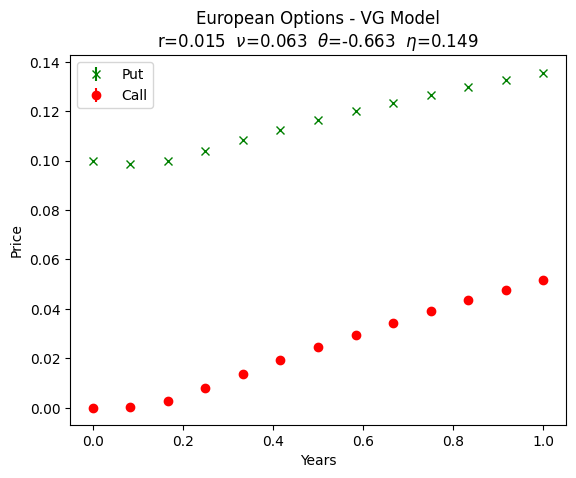

In [16]:
run()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4685fbd4-0377-4183-acc1-197b8506b05b' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>